# 01b: Data Quality Assessment

**Purpose:** Deep dive into data quality, outliers, and influential observations

**Dataset:** COMPAS (cleaned)

**Date:** 2025-11-08

---

## Overview

### Purpose
- Identify outliers in continuous features
- Detect influential observations
- Assess multicollinearity (VIF)
- Check distribution normality
- Generate quality assurance report

### Inputs
- Cleaned COMPAS data from `02a_data_cleaning.ipynb`

### Outputs
- Outlier analysis → `results/figures/exploratory/outliers_analysis.png`
- VIF report → `results/tables/vif_multicollinearity.csv`
- Quality report → `data/metadata/quality_assessment.json`

### Runtime: 2-3 minutes

---

In [22]:
# Setup
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "src"))

# Directories
PROCESSED_DIR = project_root / "data" / "processed"
FIGURES_DIR = project_root / "results" / "figures" / "exploratory"
TABLES_DIR = project_root / "results" / "tables"
METADATA_DIR = project_root / "data" / "metadata"

for d in [FIGURES_DIR, TABLES_DIR, METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Setup complete")

✓ Setup complete


## 1. Load Cleaned Data

In [23]:
# Load cleaned data
df = pd.read_parquet(PROCESSED_DIR / "compas_cleaned.parquet")
print(f"Loaded {len(df):,} samples")

# Identify continuous features
continuous_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'two_year_recid' in continuous_cols:
    continuous_cols.remove('two_year_recid')

print(f"Continuous features: {len(continuous_cols)}")

Loaded 6,172 samples
Continuous features: 19


## 2. Outlier Detection

### 2.1 IQR Method

In [26]:
# Detect outliers using IQR method
outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = n_outliers / len(df) * 100
    
    outlier_summary.append({
        'feature': col,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print("Outlier detection (IQR method):")
display(outlier_df)

Outlier detection (IQR method):


,feature,n_outliers,pct_outliers,lower_bound,upper_bound
7,days_b_screening_arrest,2192,35.515,-1.0,-1.0
8,c_days_from_compas,1836,29.747,1.0,1.0
16,start,1128,18.276,-4.5,7.5
12,is_violent_recid,692,11.212,0.0,0.0
6,priors_count,492,7.971,-6.0,10.0
15,priors_count.1,492,7.971,-6.0,10.0
5,juv_other_count,461,7.469,0.0,0.0
4,juv_misd_count,352,5.703,0.0,0.0
10,r_days_from_arrest,284,4.601,-1.5,2.5
2,juv_fel_count,208,3.370,0.0,0.0


### 2.2 Visualize Outliers

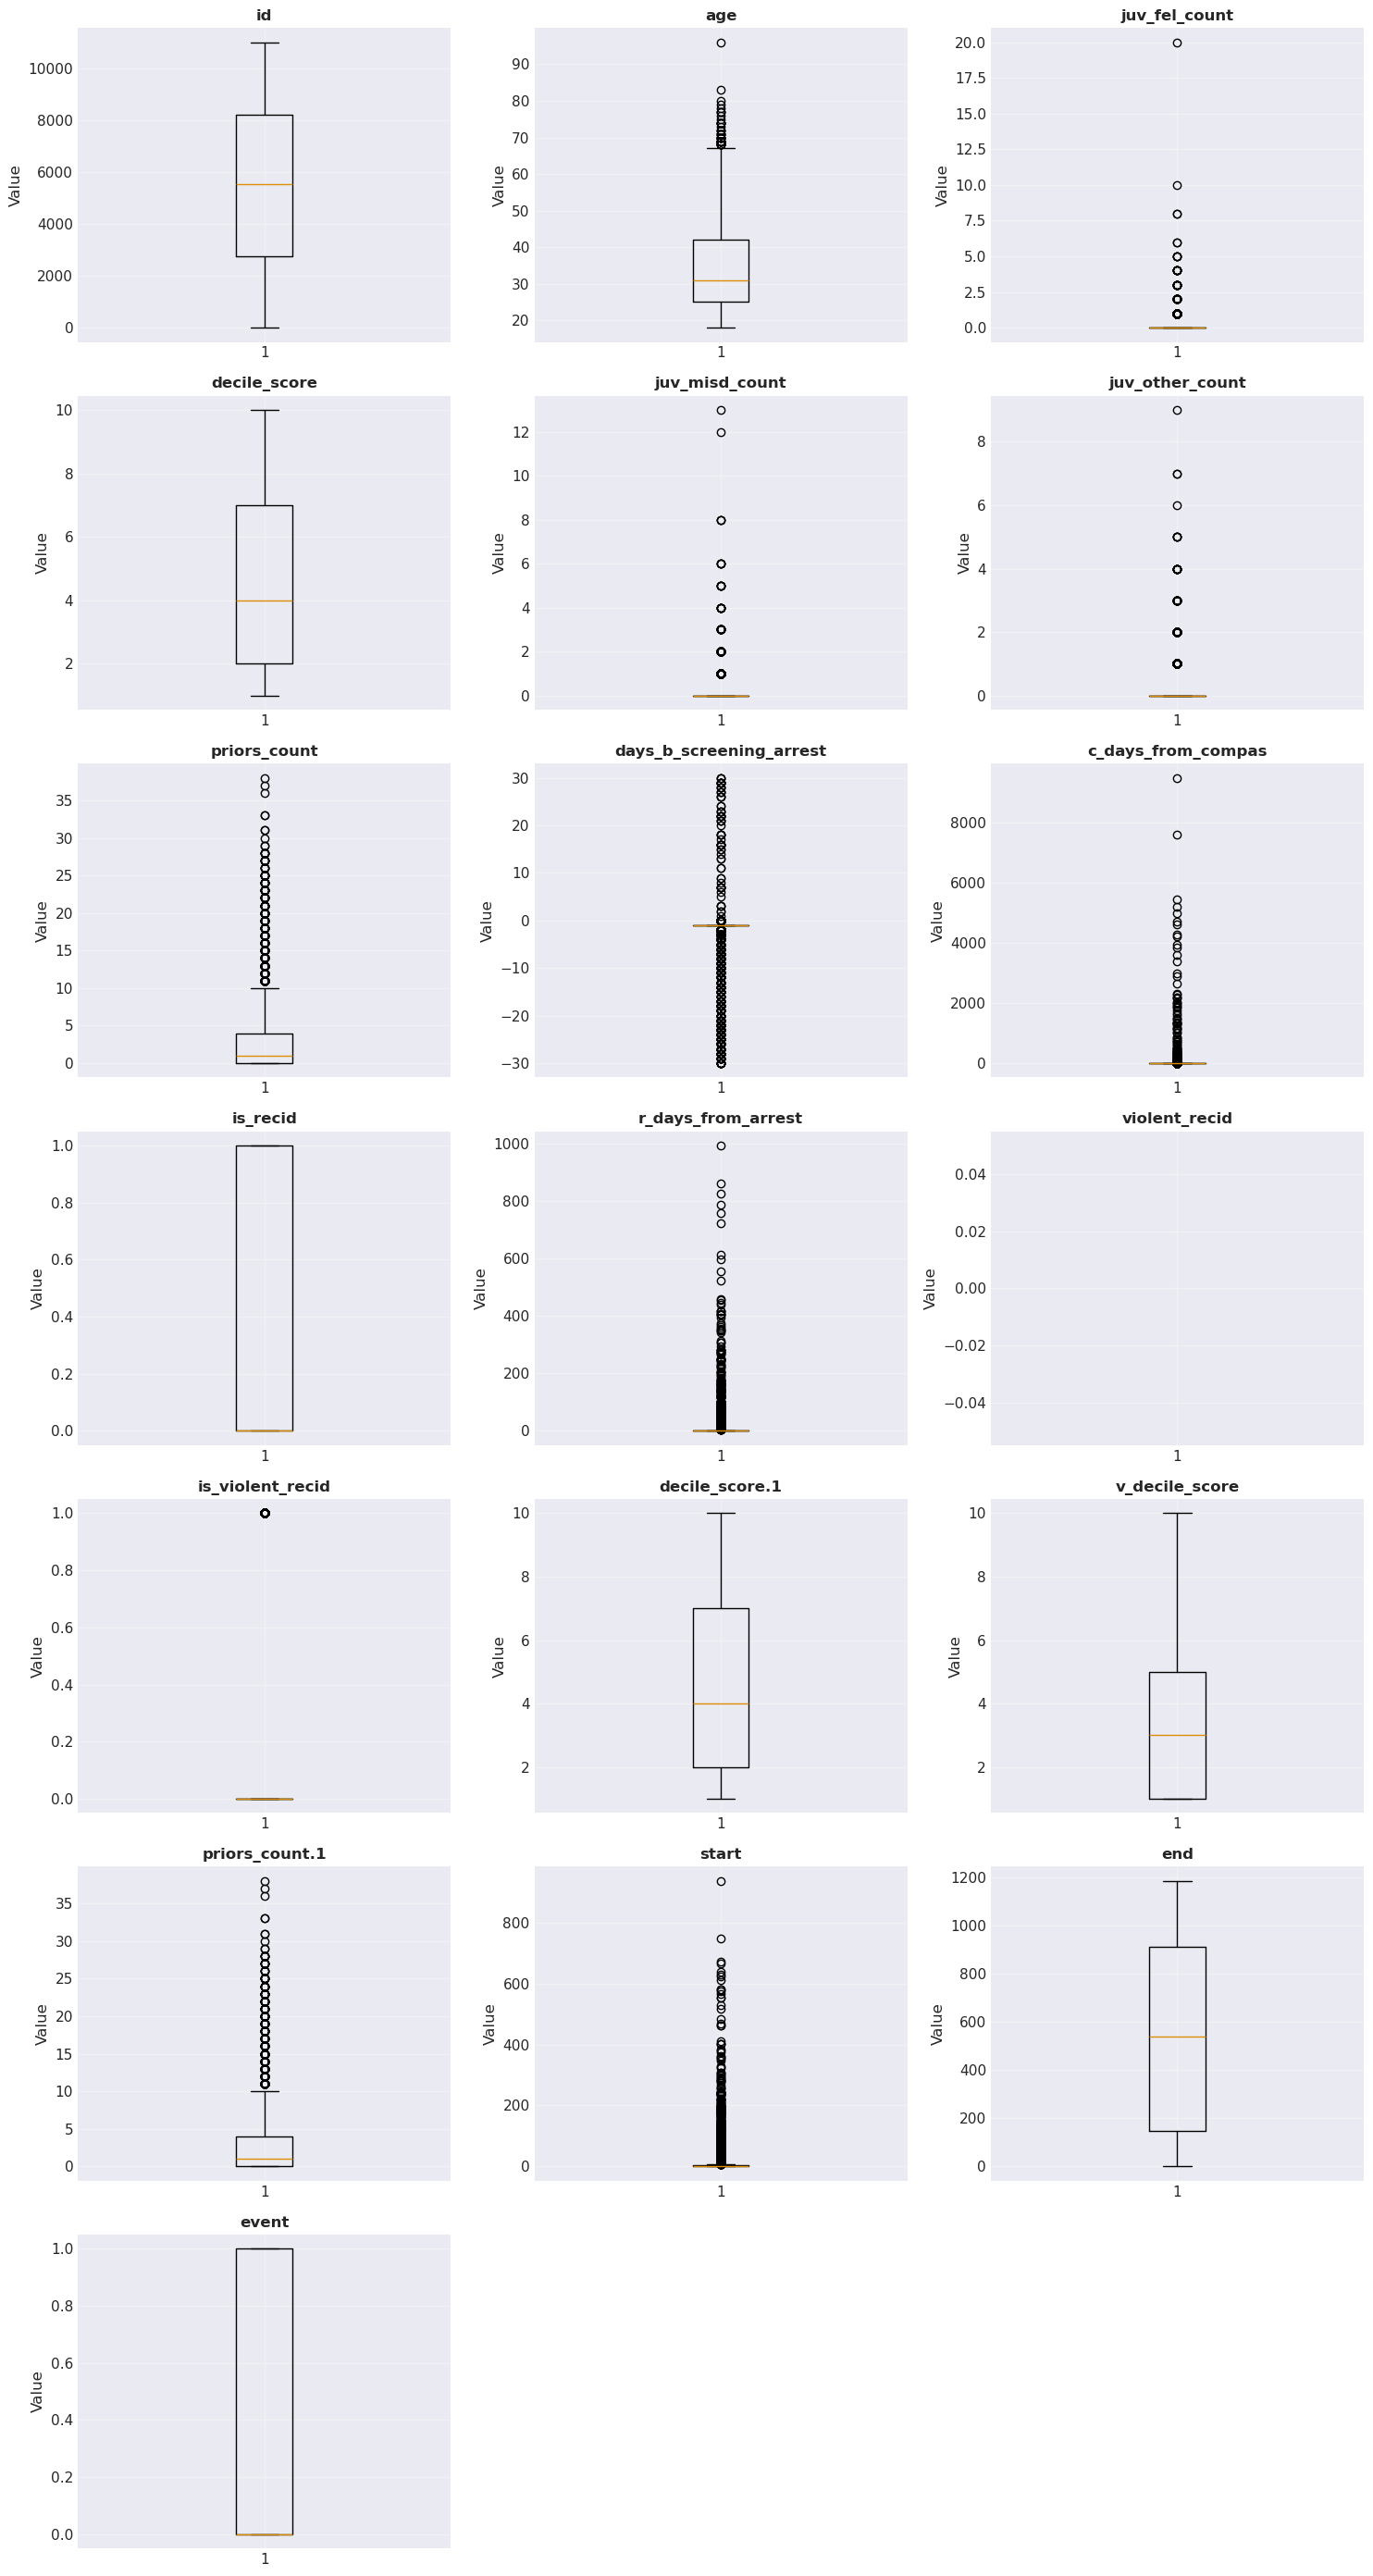

✓ Saved: outliers_boxplots.png


In [27]:
# Box plots for outlier visualization
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if len(continuous_cols) > 1 else [axes]

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3)

for i in range(len(continuous_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: outliers_boxplots.png")

In [33]:
X0 = df[continuous_cols]
all_na_cols = X0.columns[X0.isna().all()].tolist()
print("Columns that are all NA:", all_na_cols)


Columns that are all NA: ['violent_recid']


## 3. Multicollinearity Assessment

Calculate Variance Inflation Factor (VIF) to detect multicollinearity.

In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df, cols, min_row_complete=1.0, save_path=None):
    """
    Compute VIF for the given predictor columns, with robust cleaning.

    Parameters
    ----------
    df : pandas.DataFrame
    cols : list[str]       # candidate predictor columns
    min_row_complete : float in (0,1]  # require at least this fraction of non-missing predictors per row
    save_path : pathlib.Path | str | None

    Returns
    -------
    vif_df : pandas.DataFrame with columns ['feature','VIF']
    """
    # 0) Keep only existing columns
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()

    # 1) Remove columns that are entirely missing
    all_na_cols = X.columns[X.isna().all()].tolist()
    if all_na_cols:
        print("Excluding all-NA columns:", all_na_cols)
        X = X.drop(columns=all_na_cols)

    # If nothing left, bail early
    if X.shape[1] < 2:
        print(f"Not enough usable predictors after cleaning (columns={X.shape[1]}).")
        return pd.DataFrame(columns=["feature", "VIF"])

    # 2) Treat inf as missing, and enforce a row-completeness threshold
    X = X.replace([np.inf, -np.inf], np.nan)
    k = X.shape[1]
    # Require at least ceil(min_row_complete * k) non-missing predictors in each row
    thresh = int(np.ceil(min_row_complete * k))
    X = X.dropna(thresh=thresh)  # rows with too many NAs removed (default is 'how=\"any\"')  # noqa: E501

    if X.shape[0] < 2:
        print(f"Not enough rows after row-wise completeness filter (rows={X.shape[0]}).")
        return pd.DataFrame(columns=["feature", "VIF"])

    # 3) Drop zero-variance columns
    zero_var = [c for c in X.columns if np.isclose(X[c].var(ddof=0), 0)]
    if zero_var:
        print("Dropping zero-variance columns:", zero_var)
        X = X.drop(columns=zero_var)

    if X.shape[1] < 2:
        print("Not enough predictors remaining after dropping zero-variance columns.")
        return pd.DataFrame(columns=["feature", "VIF"])

    # 4) Add intercept and compute VIF for predictors (exclude constant from report)
    Xc = sm.add_constant(X, has_constant="add")
    records = []
    for i, name in enumerate(Xc.columns):
        v = variance_inflation_factor(Xc.values, i)
        records.append({"feature": name, "VIF": v})

    vif_df = (pd.DataFrame(records)
                .query("feature != 'const'")
                .sort_values("VIF", ascending=False)
                .reset_index(drop=True))

    print("Variance Inflation Factors:")
    display(vif_df)

    # Interpretation
    high_vif = vif_df[vif_df["VIF"] > 10]
    if len(high_vif) > 0:
        print(f"\nHigh multicollinearity detected ({len(high_vif)} feature(s) with VIF > 10):")
        for _, row in high_vif.iterrows():
            print(f"  - {row['feature']}: VIF = {row['VIF']:.2f}")
    else:
        print("\nNo severe multicollinearity (all VIF < 10)")

    # Optional save
    if save_path is not None:
        pd.Path = getattr(pd, "Path", None)  # no-op guard if not using pathlib
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            vif_df.to_csv(save_path, index=False)
            print(f"\nSaved: {save_path.name}")
        except Exception as e:
            print(f"\nWarning: could not save CSV ({e})")

    return vif_df

# Example usage (exclude outcome if present; violent_recid will be auto-dropped if all NA)
predictors = [c for c in continuous_cols if c != "violent_recid"]
vif_df = compute_vif(df, predictors, min_row_complete=1.0, save_path=TABLES_DIR / "vif_multicollinearity.csv")


Dropping zero-variance columns: ['is_recid']
Variance Inflation Factors:


/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,decile_score,inf
1,priors_count.1,inf
2,priors_count,inf
3,decile_score.1,inf
4,v_decile_score,2.866
5,age,1.756
6,juv_misd_count,1.177
7,juv_other_count,1.132
8,start,1.118
9,end,1.114



High multicollinearity detected (4 feature(s) with VIF > 10):
  - decile_score: VIF = inf
  - priors_count.1: VIF = inf
  - priors_count: VIF = inf
  - decile_score.1: VIF = inf

Saved: vif_multicollinearity.csv


## 4. Normality Tests

In [31]:
# Shapiro-Wilk test for normality (on sample if n > 5000)
normality_results = []

for col in continuous_cols:
    data = df[col].dropna()
    
    # Sample if too large
    if len(data) > 5000:
        data = data.sample(5000, random_state=42)
    
    stat, p_value = stats.shapiro(data)
    is_normal = p_value > 0.05
    
    normality_results.append({
        'feature': col,
        'shapiro_stat': stat,
        'p_value': p_value,
        'is_normal': is_normal
    })

normality_df = pd.DataFrame(normality_results)
print("Normality tests (Shapiro-Wilk):")
display(normality_df)

n_normal = normality_df['is_normal'].sum()
print(f"\n{n_normal} of {len(continuous_cols)} features appear normally distributed")

Normality tests (Shapiro-Wilk):


/tmp/ipykernel_1183494/4287630731.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = stats.shapiro(data)


,feature,shapiro_stat,p_value,is_normal
0,id,0.955,8.880e-37,False
1,age,0.909,1.300e-47,False
2,juv_fel_count,0.101,2.342e-93,False
3,decile_score,0.910,2.175e-47,False
4,juv_misd_count,0.176,2.462e-91,False
5,juv_other_count,0.249,3.506e-89,False
6,priors_count,0.695,8.363e-70,False
7,days_b_screening_arrest,0.401,4.224e-84,False
8,c_days_from_compas,0.060,2.180e-94,False
9,is_recid,0.636,2.002e-73,False



0 of 19 features appear normally distributed


## 5. Quality Assessment Report

In [36]:
# --- Configuration ---
VIF_THRESHOLD = 10.0  # common "serious multicollinearity" rule-of-thumb

# --- Imports & IO safety ---
import json
from pathlib import Path

# If METADATA_DIR was not defined earlier, default to a local "metadata" folder
try:
    METADATA_DIR  # noqa: F821
except NameError:
    METADATA_DIR = Path("metadata")
if isinstance(METADATA_DIR, str):
    METADATA_DIR = Path(METADATA_DIR)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

# --- Preconditions (assumes these are created earlier in your notebook) ---
# df, continuous_cols, outlier_df, vif_df, normality_df, n_normal

# --- Compute helpers used in the report ---
# List of features with high VIFs (strictly above the threshold)
high_vif = (
    vif_df.loc[vif_df["VIF"] > VIF_THRESHOLD, "feature"]
    .astype(str)
    .tolist()
)

# Max outlier percentage as a plain float (handles pandas/numpy dtypes)
max_outlier_pct = float(outlier_df["pct_outliers"].max())

# --- Compile quality assessment ---
quality_report = {
    "notebook": "01b_data_quality_assessment.ipynb",
    "n_samples": int(len(df)),
    "n_features": int(len(continuous_cols)),
    "outliers": {
        "method": "IQR (1.5 * IQR)",
        "features_with_outliers": int((outlier_df["n_outliers"] > 0).sum()),
        "max_outlier_pct": max_outlier_pct,
        "summary": outlier_df.to_dict("records"),
    },
    "multicollinearity": {
        "max_vif": float(vif_df["VIF"].max()),
        "features_high_vif": high_vif,
        "vif_summary": vif_df.to_dict("records"),
        "vif_threshold": VIF_THRESHOLD,
    },
    "normality": {
        "n_normal": int(n_normal),
        "n_non_normal": int(len(continuous_cols) - int(n_normal)),
        "summary": normality_df.to_dict("records"),
    },
    "recommendations": {
        "transformations": "Consider log transformation for non-normal count features",
        "outliers": "Most outliers appear legitimate (high prior counts), do not remove",
        "multicollinearity": (
            "No severe issues detected"
            if len(high_vif) == 0
            else "Consider removing or combining high-VIF features"
        ),
    },
}

# --- Save ---
out_path = METADATA_DIR / "quality_assessment.json"
with open(out_path, "w") as f:
    json.dump(quality_report, f, indent=2)

print("✓ Saved:", out_path.name)
print("\n" + "=" * 60)
print("DATA QUALITY ASSESSMENT COMPLETE")
print("=" * 60)
print(f"✓ Outliers detected but appear legitimate (criminal history)")
print(f"✓ No severe multicollinearity (max VIF: {vif_df['VIF'].max():.2f})")
print(f"✓ {int(n_normal)}/{len(continuous_cols)} features normally distributed")
print("\nNext: 01d_descriptive_statistics.ipynb")


✓ Saved: quality_assessment.json

DATA QUALITY ASSESSMENT COMPLETE
✓ Outliers detected but appear legitimate (criminal history)
✓ No severe multicollinearity (max VIF: inf)
✓ 0/19 features normally distributed

Next: 01d_descriptive_statistics.ipynb
